# 04: Product Analysis

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Understand which products drive revenue, identify high-abandonment SKUs, and surface product-level conversion patterns to inform advertising and inventory decisions.  
**Reference:** [GA BigQuery Export Schema](https://support.google.com/analytics/answer/3437719?hl=en)  
**Key fields:** `hits.product` (nested inside `hits`, requires double UNNEST), `hits.eCommerceAction.action_type`

## 1. Setup

In [1]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 2. Column Overview
*Key product-level fields used in this notebook*

`hits.product` is a REPEATED RECORD nested inside `hits`, so it requires double UNNEST: `UNNEST(hits) AS hits, UNNEST(hits.product) AS product`. Each row in the result represents one product interaction within one hit.

`hits.eCommerceAction.action_type` values used in this notebook:
- `2` = product detail view
- `3` = add to cart
- `6` = completed purchase

Note: `productRevenue` and `productQuantity` are only non-null for `action_type = '6'`. For views and cart adds, use hit counts rather than revenue.

Key `hits.product` fields:
- `v2ProductName` - product display name
- `v2ProductCategory` - category path (e.g. `Home/Apparel/Men's/`)
- `productSKU` - unique product identifier
- `productPrice` - unit price in micros (divide by 1,000,000 for USD)
- `productRevenue` - total line revenue in micros; only populated on purchased products
- `productQuantity` - units purchased; only populated on purchased products
- `isImpression` - `TRUE` if the product was a list impression (e.g. "You might also like"), not a direct interaction

In [2]:
# note: single-day sample to explore column structure cheaply before running full-year queries
# note: LIMIT inside subquery required - BigQuery does not allow LIMIT before UNION ALL
query_product_cols = """
SELECT * FROM (
    SELECT hits.eCommerceAction.action_type, product.isImpression,
           product.v2ProductName, product.v2ProductCategory,
           product.productSKU, product.productPrice / 1000000 AS price_usd,
           product.productRevenue / 1000000 AS revenue_usd, product.productQuantity
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20170101`,
    UNNEST(hits) AS hits, UNNEST(hits.product) AS product
    WHERE hits.eCommerceAction.action_type = '2' LIMIT 3
)
UNION ALL
SELECT * FROM (
    SELECT hits.eCommerceAction.action_type, product.isImpression,
           product.v2ProductName, product.v2ProductCategory,
           product.productSKU, product.productPrice / 1000000 AS price_usd,
           product.productRevenue / 1000000 AS revenue_usd, product.productQuantity
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20170101`,
    UNNEST(hits) AS hits, UNNEST(hits.product) AS product
    WHERE hits.eCommerceAction.action_type = '3' LIMIT 3
)
UNION ALL
SELECT * FROM (
    SELECT hits.eCommerceAction.action_type, product.isImpression,
           product.v2ProductName, product.v2ProductCategory,
           product.productSKU, product.productPrice / 1000000 AS price_usd,
           product.productRevenue / 1000000 AS revenue_usd, product.productQuantity
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20170101`,
    UNNEST(hits) AS hits, UNNEST(hits.product) AS product
    WHERE hits.eCommerceAction.action_type = '6' LIMIT 3
)
ORDER BY action_type
"""
df_product_cols = client.query(query_product_cols).to_dataframe()
df_product_cols

,action_type,isImpression,v2ProductName,v2ProductCategory,productSKU,price_usd,revenue_usd,productQuantity
0,2,<NA>,YouTube Trucker Hat,Home/Shop by Brand/YouTube/,GGOEYHPA003510,21.99,NaN,<NA>
1,2,<NA>,Waterproof Backpack,Home/Bags/,GGOEGBRA037499,99.99,NaN,<NA>
2,2,<NA>,Google Alpine Style Backpack,Home/Bags/,GGOEGBRJ037299,99.99,NaN,<NA>
3,3,<NA>,YouTube Leatherette Notebook Combo,Home/Shop by Brand/YouTube/,GGOEYOLR018699,6.99,NaN,1
4,3,<NA>,YouTube Twill Cap,${escCatTitle},GGOEYHPB072210,10.99,NaN,1
5,3,<NA>,Google Tri-blend Hoodie Grey,Home/Apparel/Men's/Men's-Outerwear/,GGOEGAAX0313,39.99,NaN,1
6,6,<NA>,Google Laptop and Cell Phone Stickers,Office,GGOEGFKQ020399,1.99,4.99,1
7,6,<NA>,Google Laptop and Cell Phone Stickers,Office,GGOEGFKQ020399,1.99,NaN,<NA>
8,6,<NA>,Google Men's Short Sleeve Hero Tee Heather,Apparel,GGOEGAAJ073415,18.99,22.49,1


### 2a. Data Scope
*How many products, SKUs, and categories exist in the dataset? Any data quality issues to flag?*

In [3]:
query_product_scope = """
SELECT
    COUNT(DISTINCT product.productSKU) AS unique_skus,
    COUNT(DISTINCT product.v2ProductName) AS unique_names,
    COUNT(DISTINCT product.v2ProductCategory) AS unique_categories,
    COUNTIF(hits.eCommerceAction.action_type = '6'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
        AND product.productRevenue IS NOT NULL) AS purchase_product_rows
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits,
UNNEST(hits.product) AS product
"""
df_scope = client.query(query_product_scope).to_dataframe()
df_scope

,unique_skus,unique_names,unique_categories,purchase_product_rows
0,1888,621,107,36818


**Observations:**

- 1,888 unique SKUs map to only 621 unique product names - each name averages ~3 SKUs (variants by size, color, etc.)
- 107 category paths in `Home/Category/Subcategory/` format
- 36,818 purchase product rows across the full year (action_type = 6, with revenue)

#### Category Tagging Bug
75,125 rows across 493 products (599 SKUs) carry `v2ProductCategory = '${escCatTitle}'` — a JS template variable that was never substituted before GA fired the tracking hit. The queries below show sample cases, measure the scale, and build a resolution map.

In [4]:
query_bad_category_sample = """
SELECT
    hits.eCommerceAction.action_type,
    product.v2ProductName,
    product.v2ProductCategory,
    product.productSKU,
    product.productPrice / 1000000 AS price_usd
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits,
UNNEST(hits.product) AS product
WHERE (product.isImpression IS NULL OR product.isImpression = FALSE)
  AND product.v2ProductCategory = '${escCatTitle}'
LIMIT 5
"""

df_bad_sample = client.query(query_bad_category_sample).to_dataframe()
display(df_bad_sample)

,action_type,v2ProductName,v2ProductCategory,productSKU,price_usd
0,3,Google Stylus Pen w/ LED Light,${escCatTitle},GGOEGOAR013099,5.50
1,3,Ballpoint LED Light Pen,${escCatTitle},GGOEGOAQ012899,2.50
2,1,YouTube Men's Vintage Henley,${escCatTitle},GGOEGAAX0351,23.99
3,2,YouTube Men's Vintage Henley,${escCatTitle},GGOEGAAX0351,23.99
4,3,YouTube Men's Vintage Henley,${escCatTitle},GGOEGAAX0351,23.99


In [5]:
query_bad_category = """
SELECT
    COUNT(*)                              AS total_rows,
    COUNT(DISTINCT product.productSKU)    AS affected_skus,
    COUNT(DISTINCT product.v2ProductName) AS affected_products
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits,
UNNEST(hits.product) AS product
WHERE (product.isImpression IS NULL OR product.isImpression = FALSE)
  AND product.v2ProductCategory = '${escCatTitle}'
"""

df_bad_category = client.query(query_bad_category).to_dataframe()
display(df_bad_category)

,total_rows,affected_skus,affected_products
0,75125,599,493


In [6]:
# build canonical product -> category map from rows with valid categories
# uses window function to pick the most frequent category per product name
query_product_category_map = """
WITH category_counts AS (
    SELECT
        product.v2ProductName,
        product.v2ProductCategory AS category,
        COUNT(*) AS row_count
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE (product.isImpression IS NULL OR product.isImpression = FALSE)
        AND product.v2ProductCategory IS NOT NULL
        AND product.v2ProductCategory != '${escCatTitle}'
    GROUP BY product.v2ProductName, product.v2ProductCategory
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY v2ProductName ORDER BY row_count DESC) AS rn
    FROM category_counts
)
SELECT v2ProductName, category AS canonical_category, row_count
FROM ranked
WHERE rn = 1
ORDER BY v2ProductName
"""

df_product_category_map = client.query(query_product_category_map).to_dataframe()
print(f"{len(df_product_category_map)} products with known canonical category")
display(df_product_category_map.head(10))

528 products with known canonical category


,v2ProductName,canonical_category,row_count
0,1 oz Hand Sanitizer,Home/Accessories/Fun/,1185
1,15 oz Ceramic Mug,Home/Drinkware/Mugs and Cups/,47
2,16 oz. Hot and Cold Tumbler,Home/Drinkware/,285
3,16 oz. Hot/Cold Tumbler,Home/Accessories/Drinkware/,171
4,20 oz Stainless Steel Insulated Tumbler,Home/Drinkware/,2960
5,22 oz Android Bottle,Bottles,1079
6,22 oz Mini Mountain Bottle,Home/Accessories/Drinkware/,635
7,22 oz YouTube Bottle Infuser,Home/Shop by Brand/YouTube/,4348
8,23 oz Wide Mouth Sport Bottle,Home/Drinkware/,974
9,24 oz USA Made Aluminum Bottle,Home/Drinkware/,711


In [7]:
df_product_category_map.to_csv('../data/product_category_map.csv', index=False)
print('saved to data/product_category_map.csv')

saved to data/product_category_map.csv


In [8]:
# check how many ${escCatTitle} products can be resolved from the map
query_resolution_check = """
WITH bad_products AS (
    SELECT
        product.v2ProductName,
        COUNT(*) AS bad_rows
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE (product.isImpression IS NULL OR product.isImpression = FALSE)
      AND product.v2ProductCategory = '${escCatTitle}'
    GROUP BY product.v2ProductName
),
category_counts AS (
    SELECT
        product.v2ProductName,
        product.v2ProductCategory,
        COUNT(*) AS cnt
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE (product.isImpression IS NULL OR product.isImpression = FALSE)
      AND product.v2ProductCategory IS NOT NULL
      AND product.v2ProductCategory != '${escCatTitle}'
    GROUP BY product.v2ProductName, product.v2ProductCategory
),
canonical AS (
    SELECT
        v2ProductName,
        ARRAY_AGG(v2ProductCategory ORDER BY cnt DESC LIMIT 1)[OFFSET(0)] AS resolved_category
    FROM category_counts
    GROUP BY v2ProductName
)
SELECT
    b.v2ProductName,
    b.bad_rows,
    c.resolved_category
FROM bad_products b
LEFT JOIN canonical c USING (v2ProductName)
ORDER BY b.bad_rows DESC
"""

df_resolution = client.query(query_resolution_check).to_dataframe()
resolvable = df_resolution['resolved_category'].notna().sum()
total = len(df_resolution)
print(f"{resolvable}/{total} distinct products with bad category can be resolved from other rows")
display(df_resolution)

488/493 distinct products with bad category can be resolved from other rows


,v2ProductName,bad_rows,resolved_category
0,Google Sunglasses,3915,Lifestyle
1,Google Men's 100% Cotton Short Sleeve Hero Tee...,1791,Home/Apparel/Men's/Men's-T-Shirts/
2,Google Laptop and Cell Phone Stickers,1651,Home/Accessories/Stickers/
3,YouTube Men's Short Sleeve Hero Tee Black,1504,Home/Shop by Brand/YouTube/
4,YouTube Custom Decals,1432,Home/Shop by Brand/YouTube/
...,...,...,...
488,Android 14 oz Mug White/Green,1,Home/Drinkware/Mugs and Cups/
489,Google Leather Journal-Brown,1,Notebooks & Journals
490,Google Sunglasses Yellow,1,Lifestyle
491,Google Women's Badge Performance Tee Black,1,Apparel


**Observations:**

- 75,125 rows (across 493 products) carry `'${escCatTitle}'` instead of a real category - a tagging bug where the JS variable was never resolved before GA fired
- 488/493 affected products appear elsewhere with valid categories and are covered by `df_product_category_map`; 5 products are unresolvable
- Highest-impact products: Google Sunglasses (3,915 bad rows), Google Men's 100% Cotton Short Sleeve Hero Tee (1,791), Google Laptop and Cell Phone Stickers (1,651)

### 2b. Category Normalization & Brand Tagging
*Normalize category strings to 8 consistent groups; extract brand from product name.*

In [9]:
def normalize_category(name, category):
    c = str(category)
    # keyword-in-category string; Drinkware checked before Accessories
    # to correctly handle Home/Accessories/Drinkware/
    if 'Drinkware'   in c: return 'Drinkware'
    if 'Apparel'     in c: return 'Apparel'
    if 'Electronics' in c: return 'Electronics'
    if 'Bags'        in c: return 'Bags'
    if 'Office'      in c: return 'Office'
    if 'Accessories' in c: return 'Accessories'
    if 'Lifestyle'   in c: return 'Lifestyle'
    if 'Gift Cards'  in c: return 'Gift Cards'

    # name-based fallback for flat/brand categories: Headgear, Bottles, Notebooks & Journals,
    # Android, Google, Waze, (not set), Home/Fruit Games/, Home/Shop by Brand/YouTube/
    n = name.lower()
    if any(k in n for k in ['bottle', 'tumbler', 'mug', 'cup', 'koozie', 'infuser', 'contigo']):
        return 'Drinkware'
    if any(k in n for k in ['tee', 'shirt', 'hoodie', 'jacket', 'vest', 'onesie', 'tank',
                              'fleece', 'henley', 'raglan', 'pullover', 'cardigan', 'socks',
                              'hat', 'cap', 'sweatshirt', 'polo', 'baby', 'toddler']):
        return 'Apparel'
    if any(k in n for k in ['sticker', 'decal', 'luggage tag', 'frisbee', 'disc', 'feeding mat']):
        return 'Accessories'
    if any(k in n for k in ['bag', 'backpack', 'rucksack', 'tote', 'shopper', 'duffel']):
        return 'Bags'
    if any(k in n for k in ['journal', 'notebook', 'pen', 'pencil', 'crayon', 'highlighter']):
        return 'Office'
    if any(k in n for k in ['speaker', 'headphone', 'earbud', 'charger', 'flashlight',
                              'bluetooth', 'powerbank', 'power bank']):
        return 'Electronics'
    return 'Other'


def extract_brand(name):
    n = name.lower()
    if 'youtube' in n: return 'YouTube'
    if 'android' in n: return 'Android'
    if 'waze'    in n: return 'Waze'
    if 'google'  in n: return 'Google'
    return 'Other'


df_product_category_norm = df_product_category_map.copy()
df_product_category_norm['normalized_category'] = df_product_category_norm.apply(
    lambda r: normalize_category(r['v2ProductName'], r['canonical_category']), axis=1
)
df_product_category_norm['brand'] = df_product_category_norm['v2ProductName'].apply(extract_brand)

print('--- normalized_category ---')
print(df_product_category_norm['normalized_category'].value_counts().to_string())
print()
print('--- brand ---')
print(df_product_category_norm['brand'].value_counts().to_string())

df_product_category_norm.to_csv('../data/product_category_normalized.csv', index=False)
print('\nsaved to data/product_category_normalized.csv')

--- normalized_category ---
normalized_category
Apparel        288
Office          71
Drinkware       42
Electronics     39
Accessories     34
Bags            34
Lifestyle       16
Gift Cards       4

--- brand ---
brand
Google     268
Other      133
Android     75
YouTube     41
Waze        11

saved to data/product_category_normalized.csv


In [10]:
# spot-check: anything that fell through to 'Other'
others = df_product_category_norm[df_product_category_norm['normalized_category'] == 'Other']
pd.set_option('display.max_colwidth', None)
display(others[['v2ProductName', 'canonical_category']])

,v2ProductName,canonical_category


**Observations:**

- `df_product_category_map` has 53 distinct canonical category strings (from the 528 products with valid categories); the 107 in the scope query included all action types and no isImpression filter - a broader population
- 53 strings collapse to 8 normalized categories; 0 products unresolved
- **Apparel** dominates the catalog (287 of 528 products, 54%) - the store is primarily a branded apparel shop
- **Google is the dominant brand** (268 of 528 products, 51%); ~25% of products carry no brand keyword

## 3. Top Products by Revenue & Transactions
*Which individual products generate the most revenue and transactions across the full year?*

All queries from this section onwards apply two standard filters:
- `product.isImpression IS NULL OR product.isImpression = FALSE` - exclude list impressions, keep only direct interactions
- `product.productRevenue IS NOT NULL` - for revenue queries, ensure the product was actually purchased

In [11]:
query_top_products = """
SELECT
    product.v2ProductName AS product_name,
    ROUND(SUM(product.productRevenue / 1000000),2) AS total_revenue,
    COUNT(*) AS purchase_rows,
    SUM(product.productQuantity) AS total_units
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits,
UNNEST(hits.product) AS product
WHERE trafficSource.source != 'analytics.google.com'
    AND hits.eCommerceAction.action_type = '6'
    AND (product.isImpression IS NULL OR product.isImpression = FALSE)
    AND product.productRevenue IS NOT NULL
GROUP BY product_name
ORDER BY total_revenue DESC
"""
df_top_products = client.query(query_top_products).to_dataframe()
df_top_products = df_top_products.merge(
    df_product_category_norm[['v2ProductName', 'normalized_category', 'brand']],
    left_on='product_name', right_on='v2ProductName', how='left'
).drop(columns='v2ProductName')

# derived metrics
df_top_products['unit_price'] = (df_top_products['total_revenue'] / df_top_products['total_units']).round(2)
df_top_products['units_per_purchase'] = (df_top_products['total_units'] / df_top_products['purchase_rows']).round(1)
df_top_products['revenue_rank'] = df_top_products['total_revenue'].rank(ascending=False).astype(int)
df_top_products['purchase_rank'] = df_top_products['purchase_rows'].rank(ascending=False).astype(int)
df_top_products['unit_rank'] = df_top_products['total_units'].rank(ascending=False).astype(int)

pd.set_option("display.max_colwidth", None)
display(df_top_products.head(15))

,product_name,total_revenue,purchase_rows,total_units,normalized_category,brand,unit_price,units_per_purchase,revenue_rank,purchase_rank,unit_rank
0,Google Men's Zip Hoodie,47636.27,468,944,Apparel,Google,50.46,2.0,1,7,59
1,26 oz Double Wall Insulated Bottle,44454.49,394,2070,Drinkware,Other,21.48,5.3,2,12,30
2,Google 22 oz Water Bottle,42995.04,784,15206,Drinkware,Google,2.83,19.4,3,3,2
3,Leatherette Journal,38563.46,296,4058,Office,Other,9.5,13.7,4,23,16
4,Google Sunglasses,35490.32,1364,10981,Lifestyle,Google,3.23,8.1,5,1,3
5,Google Metallic Notebook Set,28846.60,281,5447,Office,Google,5.3,19.4,6,25,7
6,Google Men's 100% Cotton Short Sleeve Hero Tee Black,28047.61,715,1717,Apparel,Google,16.34,2.4,7,5,38
7,Recycled Paper Journal Set,27918.17,431,7800,Office,Other,3.58,18.1,8,8,4
8,Google Men's 100% Cotton Short Sleeve Hero Tee White,27856.02,760,1759,Apparel,Google,15.84,2.3,9,4,37
9,Google Hard Cover Journal,25432.67,109,1825,Office,Google,13.94,16.7,10,95,35


**Insights:**

- **Apparel and Drinkware lead at the top:** Zip Hoodie (#1) and two water bottles (#2, #3) take the top 3 spots; Office items (journals, notebooks) have the most representation with 4 of the top 15
- **Zip Hoodie leads revenue** at `$50.46`/unit - driven by price, not transaction volume
- **Bulk orders dominate journals and bottles:** Water Bottle averages 19.4 units/purchase at `$2.83`/unit; Hard Cover Journal (purchase_rank=95) averages 16.7 units/purchase - signals corporate gifting rather than individual retail
- **Sunglasses ranks #1 in purchases** (1,364 transactions) at 8.1 units/purchase - high-frequency bulk buying spread across many orders
- **Waterproof Backpack** (`$88.90`/unit, 1.7 units/purchase, purchase_rank=77) is the only premium individually-bought item in the top 15
- **Google brand dominates:** 9 of 15 top-revenue products are Google-branded; 2 unbranded items crack the top 5 (26 oz Insulated Bottle #2, Leatherette Journal #4) suggesting unbranded basics have strong standalone appeal; YouTube appears once (#14)

## 4. Revenue Concentration (Pareto)
*What share of revenue comes from the top 20% of products? Is there a long tail or do a few SKUs dominate?*

A Pareto analysis shows whether to concentrate advertising on a small set of high-performing products or spread investment across a broader catalogue.

In [12]:
# note: df_top_products already contains all products sorted by revenue from Section 3
df_pareto = df_top_products[['product_name', 'total_revenue', 'normalized_category', 'brand']].copy()
total_rev = df_pareto['total_revenue'].sum()
n_products = len(df_pareto)

df_pareto['cumul_revenue']     = df_pareto['total_revenue'].cumsum()
df_pareto['cumul_revenue_pct'] = (df_pareto['cumul_revenue'] / total_rev * 100).round(2)
df_pareto['product_rank']      = range(1, n_products + 1)
df_pareto['product_pct']       = (df_pareto['product_rank'] / n_products * 100).round(2)

df_pareto.head(5)

,product_name,total_revenue,normalized_category,brand,cumul_revenue,cumul_revenue_pct,product_rank,product_pct
0,Google Men's Zip Hoodie,47636.27,Apparel,Google,47636.27,2.73,1,0.20
1,26 oz Double Wall Insulated Bottle,44454.49,Drinkware,Other,92090.76,5.29,2,0.41
2,Google 22 oz Water Bottle,42995.04,Drinkware,Google,135085.80,7.75,3,0.61
3,Leatherette Journal,38563.46,Office,Other,173649.26,9.97,4,0.82
4,Google Sunglasses,35490.32,Lifestyle,Google,209139.58,12.01,5,1.02


In [13]:
# key thresholds
for pct in [10, 20, 50]:
    n = max(1, round(n_products * pct / 100))
    rev_pct = df_pareto.iloc[n - 1]['cumul_revenue_pct']
    print(f'Top {pct:2d}% of products ({n:3d} products) → {rev_pct:.1f}% of revenue')

for n in [1, 5, 10, 20]:
    rev_pct = df_pareto.iloc[n - 1]['cumul_revenue_pct']
    print(f'Top {n:2d} products → {rev_pct:.1f}% of revenue')

Top 10% of products ( 49 products) → 51.0% of revenue
Top 20% of products ( 98 products) → 69.4% of revenue
Top 50% of products (245 products) → 92.5% of revenue
Top  1 products → 2.7% of revenue
Top  5 products → 12.0% of revenue
Top 10 products → 19.9% of revenue
Top 20 products → 30.9% of revenue


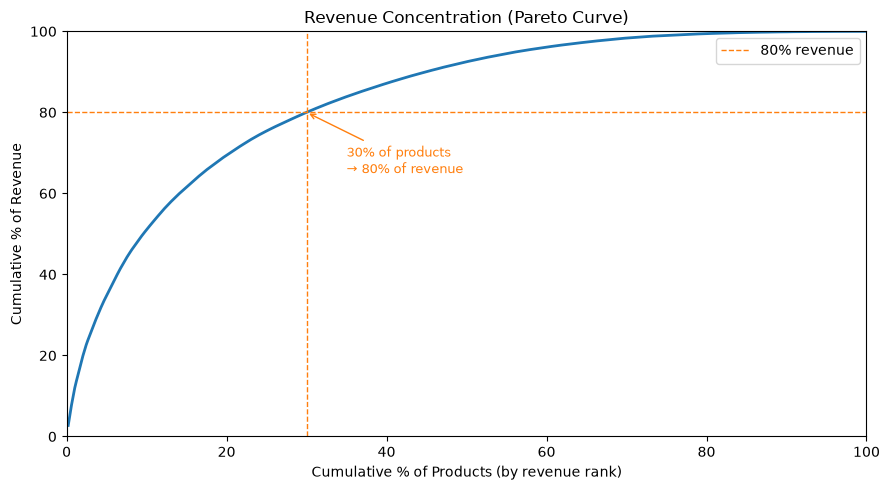

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_pareto['product_pct'], df_pareto['cumul_revenue_pct'],
        color='tab:blue', linewidth=2)
ax.axhline(80, color='tab:orange', linestyle='--', linewidth=1, label='80% revenue')

# mark the point where cumulative revenue crosses 80%
cross = df_pareto[df_pareto['cumul_revenue_pct'] >= 80].iloc[0]
ax.axvline(cross['product_pct'], color='tab:orange', linestyle='--', linewidth=1)
ax.annotate(f"{cross['product_pct']:.0f}% of products\n→ 80% of revenue",
            xy=(cross['product_pct'], 80),
            xytext=(cross['product_pct'] + 5, 65),
            fontsize=9, color='tab:orange',
            arrowprops=dict(arrowstyle='->', color='tab:orange'))

ax.set_xlabel('Cumulative % of Products (by revenue rank)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Revenue Concentration (Pareto Curve)')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('../images/revenue_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Revenue is more evenly spread than a classic Pareto rule:** the top 20% of products (98 products) account for 69.4% of revenue - notable concentration but short of the 80/20 benchmark; 80% of revenue requires ~30% of products
- **The long tail is thin:** the bottom 50% of products contribute only 7.5% of revenue (100% - 92.5%), meaning half the catalog is largely irrelevant to revenue
- **No single product dominates:** the top product (Zip Hoodie) drives only 2.7% of total revenue, and the top 10 combined reach just 19.9% - revenue is distributed across dozens of products rather than concentrated in a few items
- **Implication for inventory and marketing:** the top 49 products (10% of catalog) deliver 51% of revenue - a manageable set to prioritize for stock, promotions, and product page optimization

## 5. Top Product Categories
*Which product categories drive the most revenue and transactions?*

Uses `normalized_category` from `df_product_category_norm` (Section 2b) - 53 raw GA category strings normalized to 8 consistent groups.

In [15]:
# note: aggregating from df_top_products - no new query needed
df_by_category = (
    df_top_products
    .dropna(subset=['normalized_category'])
    .groupby('normalized_category', as_index=False)
    .agg(
        total_revenue=('total_revenue',  'sum'),
        purchase_rows=('purchase_rows',  'sum'),
        total_units  =('total_units',    'sum'),
        product_count=('product_name',   'count')
    )
    .sort_values('total_revenue', ascending=False)
)
df_by_category['revenue_share_pct'] = (
    df_by_category['total_revenue'] / df_by_category['total_revenue'].sum() * 100
).round(1)
df_by_category['avg_revenue_per_purchase'] = (
    df_by_category['total_revenue'] / df_by_category['purchase_rows']
).round(2)

display(df_by_category)

,normalized_category,total_revenue,purchase_rows,total_units,product_count,revenue_share_pct,avg_revenue_per_purchase
1,Apparel,684852.88,17273,30641,271,39.3,39.65
7,Office,358065.85,5458,94669,65,20.6,65.6
3,Drinkware,255828.90,4429,38290,37,14.7,57.76
2,Bags,174841.94,2200,15937,32,10.0,79.47
4,Electronics,135409.35,1854,13015,37,7.8,73.04
0,Accessories,77034.31,3657,30264,29,4.4,21.06
6,Lifestyle,44724.27,1711,13074,15,2.6,26.14
5,Gift Cards,11289.49,236,259,4,0.6,47.84


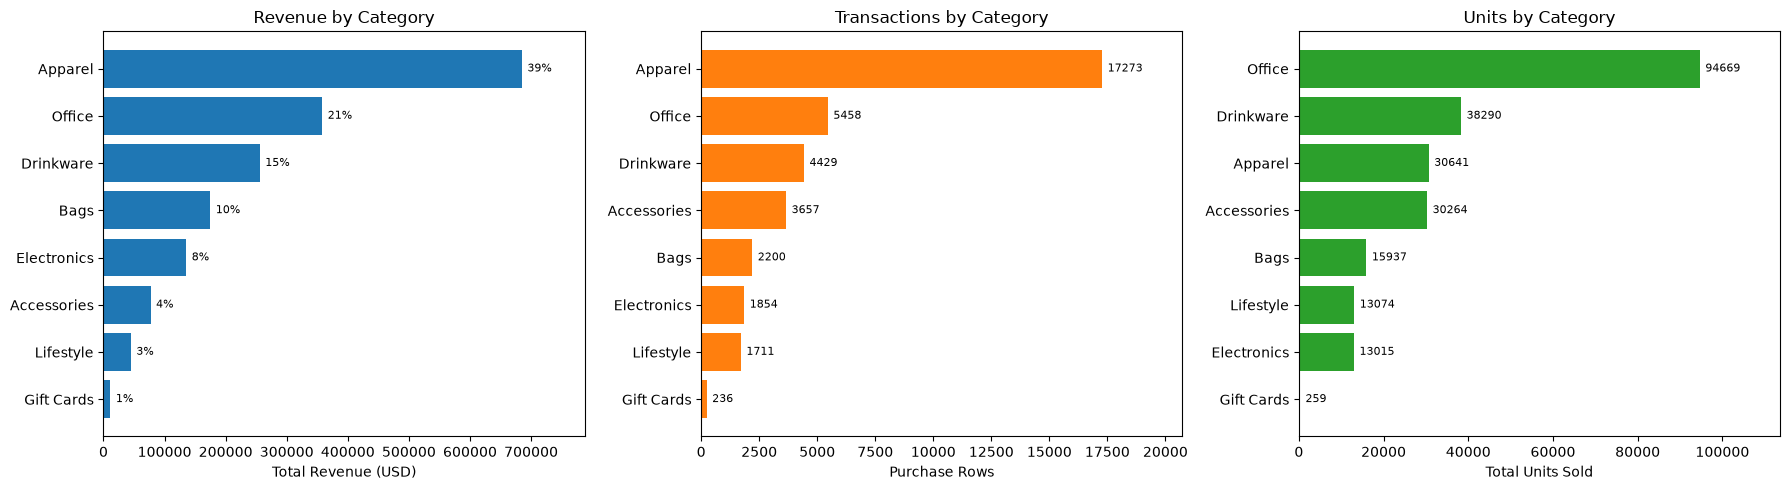

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_rev = df_by_category.sort_values('total_revenue')
df_txn = df_by_category.sort_values('purchase_rows')
df_unt = df_by_category.sort_values('total_units')

# left: revenue by category
ax = axes[0]
bars = ax.barh(df_rev['normalized_category'], df_rev['total_revenue'], color='tab:blue')
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in df_rev['revenue_share_pct']],
             padding=4, fontsize=8)
ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Revenue by Category')
ax.margins(x=0.15)

# middle: purchase rows by category
ax2 = axes[1]
bars2 = ax2.barh(df_txn['normalized_category'], df_txn['purchase_rows'], color='tab:orange')
ax2.bar_label(bars2, fmt='%d', padding=4, fontsize=8)
ax2.set_xlabel('Purchase Rows')
ax2.set_title('Transactions by Category')
ax2.margins(x=0.2)

# right: total units by category
ax3 = axes[2]
bars3 = ax3.barh(df_unt['normalized_category'], df_unt['total_units'], color='tab:green')
ax3.bar_label(bars3, fmt='%d', padding=4, fontsize=8)
ax3.set_xlabel('Total Units Sold')
ax3.set_title('Units by Category')
ax3.margins(x=0.2)

plt.tight_layout()
plt.savefig('../images/category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Apparel dominates revenue** (39.3%, `$684K`, 17,239 purchase rows) - more than the next three categories combined
- **Office leads in units sold** (94,669 units, nearly 3x Apparel's 30,560) but captures only 20.6% of revenue - journals and notebooks are bought in large bulk orders at low unit prices (`$3.78`/unit effective avg)
- **Bags has the highest avg revenue per purchase** (`$79.47`) despite ranking 4th in total revenue - buyers spend more per order when purchasing bags, possibly due to higher unit price
- **Accessories has high transaction count** (3,691 purchase rows, 3rd) but low spend (`$20.95` avg per purchase) - high-volume, low-value transactions typical of stickers and small items
- **Gift Cards and Lifestyle are marginal** at 0.6% and 2.6% of revenue - minor categories unlikely to move the needle on overall performance

## 6. Product Page Conversion (Detail View → Add to Cart)
*Which products are frequently viewed but rarely added to cart?*

`action_type = '2'` = product detail view, `action_type = '3'` = add to cart. A low view-to-cart rate on a high-traffic product suggests a pricing, description, or image problem.

In [17]:
query_view_to_cart = """
WITH detail_views AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '2'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
    GROUP BY fullVisitorId, visitId, product_name
),
add_to_carts AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '3'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
    GROUP BY fullVisitorId, visitId, product_name
)
SELECT
    d.product_name,
    COUNT(*)         AS sessions_viewed,
    COUNT(a.visitId) AS sessions_added_to_cart,
    ROUND(SAFE_DIVIDE(COUNT(a.visitId), COUNT(*)) * 100, 1) AS view_to_cart_pct
FROM detail_views d
LEFT JOIN add_to_carts a USING (fullVisitorId, visitId, product_name)
GROUP BY d.product_name
ORDER BY sessions_viewed DESC
"""

df_view_to_cart = client.query(query_view_to_cart).to_dataframe()
df_view_to_cart = df_view_to_cart.merge(
    df_product_category_norm[['v2ProductName', 'normalized_category', 'brand']],
    left_on='product_name', right_on='v2ProductName', how='left'
).drop(columns='v2ProductName')

df_vtc = df_view_to_cart[df_view_to_cart['sessions_viewed'] >= 10].copy()
df_vtc['missed_carts'] = df_vtc['sessions_viewed'] - df_vtc['sessions_added_to_cart']

print(f"Products with >=10 detail-view sessions: {len(df_vtc)}")
print(f"Median view-to-cart rate: {df_vtc['view_to_cart_pct'].median():.1f}%")
print(f"\nTop 20 most-viewed products:")
df_vtc.head(20)[['product_name', 'sessions_viewed', 'sessions_added_to_cart', 'view_to_cart_pct', 'normalized_category']]

Products with >=10 detail-view sessions: 459
Median view-to-cart rate: 32.3%

Top 20 most-viewed products:


,product_name,sessions_viewed,sessions_added_to_cart,view_to_cart_pct,normalized_category
0,Google Men's 100% Cotton Short Sleeve Hero Tee White,7909,2968,37.5,Apparel
1,Google Alpine Style Backpack,5776,680,11.8,Bags
2,Waterproof Backpack,5547,610,11.0,Bags
3,Google Men's Zip Hoodie,5067,1442,28.5,Apparel
4,Google Laptop and Cell Phone Stickers,4996,2996,60.0,Accessories
5,Google Rucksack,4445,493,11.1,Bags
6,Keyboard DOT Sticker,4389,687,15.7,Accessories
7,YouTube Custom Decals,4309,1923,44.6,Accessories
8,26 oz Double Wall Insulated Bottle,3424,1249,36.5,Drinkware
9,Google Laptop Backpack,3395,376,11.1,Bags


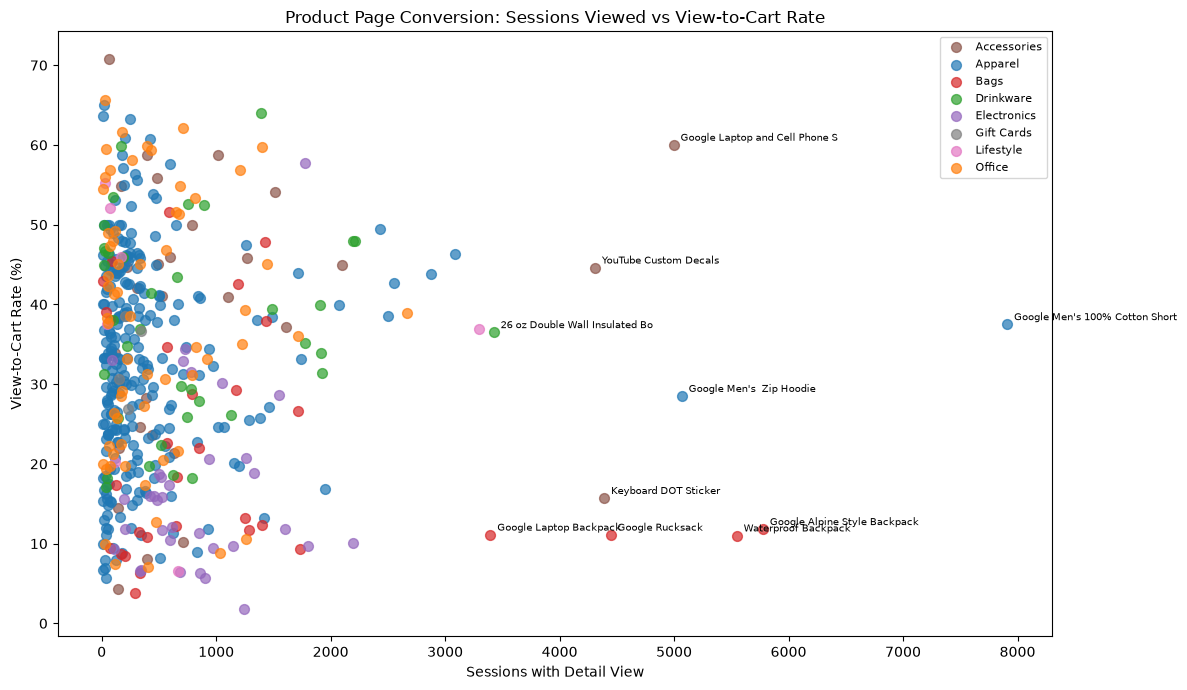

In [18]:
cat_colors = {
    'Apparel': 'tab:blue', 'Office': 'tab:orange', 'Drinkware': 'tab:green',
    'Bags': 'tab:red', 'Electronics': 'tab:purple', 'Accessories': 'tab:brown',
    'Lifestyle': 'tab:pink', 'Gift Cards': 'tab:gray'
}

fig, ax = plt.subplots(figsize=(12, 7))

for cat, grp in df_vtc.groupby('normalized_category'):
    ax.scatter(grp['sessions_viewed'], grp['view_to_cart_pct'],
               color=cat_colors.get(cat, 'tab:gray'), label=cat, alpha=0.7, s=50)

for _, row in df_vtc.nlargest(10, 'sessions_viewed').iterrows():
    ax.annotate(row['product_name'][:30],
                xy=(row['sessions_viewed'], row['view_to_cart_pct']),
                xytext=(5, 3), textcoords='offset points', fontsize=7)

ax.set_xlabel('Sessions with Detail View')
ax.set_ylabel('View-to-Cart Rate (%)')
ax.set_title('Product Page Conversion: Sessions Viewed vs View-to-Cart Rate')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../images/view_to_cart_product_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

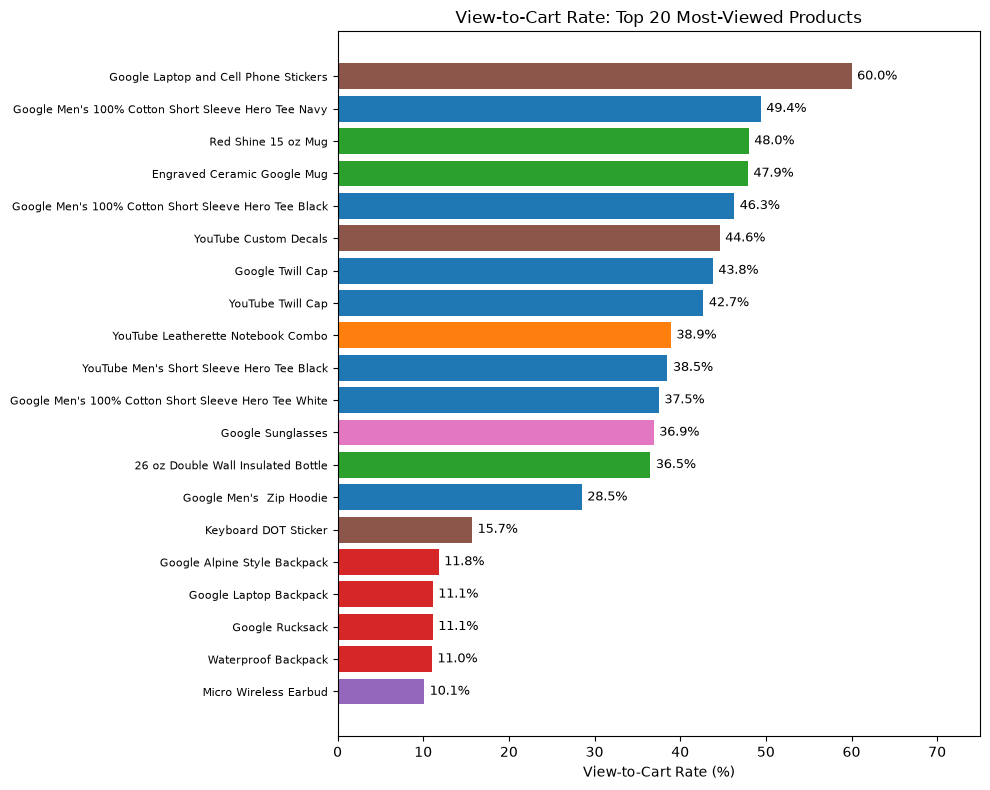

In [19]:
top20 = df_vtc.nlargest(20, 'sessions_viewed').sort_values('view_to_cart_pct')
bar_colors = [cat_colors.get(c, 'tab:gray') for c in top20['normalized_category']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20['product_name'], top20['view_to_cart_pct'], color=bar_colors)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('View-to-Cart Rate (%)')
ax.set_title('View-to-Cart Rate: Top 20 Most-Viewed Products')
ax.tick_params(axis='y', labelsize=8)
ax.margins(x=0.25)

plt.tight_layout()
plt.savefig('../images/view_to_cart_product_bar.png', dpi=150, bbox_inches='tight')
plt.show()

normalized_category  sessions_viewed  sessions_added_to_cart  view_to_cart_pct  product_count
               Bags            38594                    6852              17.8             32
        Electronics            28867                    5199              18.0             35
          Lifestyle             4394                    1433              32.6              7
         Gift Cards              930                     313              33.7              4
            Apparel           102136                   34569              33.8            253
          Drinkware            28999                   11024              38.0             37
             Office            28202                   10717              38.0             62
        Accessories            29793                   12204              41.0             29


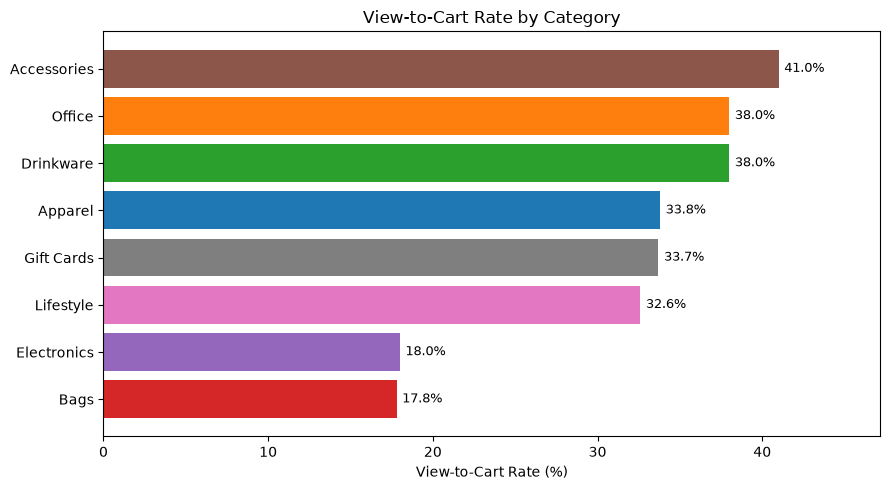

In [20]:
df_vtc_by_cat = (
    df_vtc
    .dropna(subset=['normalized_category'])
    .groupby('normalized_category', as_index=False)
    .agg(
        sessions_viewed        =('sessions_viewed',         'sum'),
        sessions_added_to_cart =('sessions_added_to_cart',  'sum'),
        product_count          =('product_name',            'count')
    )
)
df_vtc_by_cat['view_to_cart_pct'] = (
    df_vtc_by_cat['sessions_added_to_cart'] / df_vtc_by_cat['sessions_viewed'] * 100
).round(1)
df_vtc_by_cat = df_vtc_by_cat.sort_values('view_to_cart_pct')

print(df_vtc_by_cat[['normalized_category', 'sessions_viewed', 'sessions_added_to_cart', 'view_to_cart_pct', 'product_count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [cat_colors.get(c, 'tab:gray') for c in df_vtc_by_cat['normalized_category']]
bars = ax.barh(df_vtc_by_cat['normalized_category'], df_vtc_by_cat['view_to_cart_pct'], color=bar_colors)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('View-to-Cart Rate (%)')
ax.set_title('View-to-Cart Rate by Category')
ax.margins(x=0.15)

plt.tight_layout()
plt.savefig('../images/view_to_cart_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Accessories convert best at category level (41.0%)** - driven by stickers and decals; cheap impulse items see near-immediate add-to-cart decisions once a shopper lands on the page
- **Bags and Electronics are the weakest converters (~18%)** - both carry higher price points and are high-consideration purchases; shoppers browse but hesitate to commit, which also explains why Bags command the highest avg revenue per purchase (`$79.47`) yet struggle to convert views
- **Drinkware and Office tie at 38.0%** - practical, frequently gifted items that convert efficiently once viewed
- **Apparel dominates in raw traffic** (nearly 3x the next largest category) at a solid 33.8% conversion - incremental improvement here has outsized impact given the volume
- **At product level, the spread is wide**: Laptop & Cell Phone Stickers tops at 60.0%; the four most-viewed bag products (backpacks) cluster around 11%; the White Hero Tee leads in volume (7,909 sessions) at 37.5%

## 7. Cart-to-Purchase Conversion by Product (Add to Cart → Purchase)
*Which products are frequently added to cart but not purchased?*

`action_type = '3'` = add to cart, `action_type = '6'` = completed purchase. For each session that added a product to cart, we measure whether that same session completed a purchase of that product — reported as cart-to-purchase rate (consistent with the view-to-cart rate in Section 6).

**Why checkout is excluded:** Checkout (`action_type = '5'`) sits between add-to-cart and purchase but is a session-level event — a session enters checkout once for the whole cart, not per product — so it cannot be attributed meaningfully to individual products. Checkout drop-off was already analyzed at the session level in `03_funnel_analysis.ipynb`.

In [21]:
query_cart_to_purchase = """
WITH add_to_carts AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '3'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
    GROUP BY fullVisitorId, visitId, product_name
),
purchases AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '6'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
        AND product.productRevenue IS NOT NULL
    GROUP BY fullVisitorId, visitId, product_name
)
SELECT
    a.product_name,
    COUNT(*)         AS sessions_added_to_cart,
    COUNT(p.visitId) AS sessions_purchased,
    ROUND(SAFE_DIVIDE(COUNT(p.visitId),      COUNT(*)) * 100, 1) AS cart_to_purchase_pct,
    ROUND(100 - SAFE_DIVIDE(COUNT(p.visitId), COUNT(*)) * 100, 1) AS abandonment_pct
FROM add_to_carts a
LEFT JOIN purchases p USING (fullVisitorId, visitId, product_name)
GROUP BY a.product_name
ORDER BY sessions_added_to_cart DESC
"""

df_cart_to_purchase = client.query(query_cart_to_purchase).to_dataframe()
df_cart_to_purchase = df_cart_to_purchase.merge(
    df_product_category_norm[['v2ProductName', 'normalized_category', 'brand']],
    left_on='product_name', right_on='v2ProductName', how='left'
).drop(columns='v2ProductName')

df_ca = df_cart_to_purchase[df_cart_to_purchase['sessions_added_to_cart'] >= 10].copy()
df_ca['missed_purchases'] = df_ca['sessions_added_to_cart'] - df_ca['sessions_purchased']

print(f"Products with >=10 add-to-cart sessions: {len(df_ca)}")
print(f"Median cart-to-purchase rate: {df_ca['cart_to_purchase_pct'].median():.1f}%")
print(f"\nTop 20 most added-to-cart products:")
df_ca.head(20)[['product_name', 'sessions_added_to_cart', 'sessions_purchased', 'cart_to_purchase_pct', 'abandonment_pct', 'normalized_category']]

Products with >=10 add-to-cart sessions: 442
Median cart-to-purchase rate: 25.4%

Top 20 most added-to-cart products:


,product_name,sessions_added_to_cart,sessions_purchased,cart_to_purchase_pct,abandonment_pct,normalized_category
0,Google Laptop and Cell Phone Stickers,3138,673,21.4,78.6,Accessories
1,Google Men's 100% Cotton Short Sleeve Hero Tee White,3071,567,18.5,81.5,Apparel
2,YouTube Custom Decals,2057,289,14.0,86.0,Accessories
3,Google Men's 100% Cotton Short Sleeve Hero Tee Black,1550,427,27.5,72.5,Apparel
4,Google Sunglasses,1549,445,28.7,71.3,Lifestyle
5,Google Men's Zip Hoodie,1535,382,24.9,75.1,Apparel
6,Google Twill Cap,1333,356,26.7,73.3,Apparel
7,Google Men's 100% Cotton Short Sleeve Hero Tee Navy,1311,381,29.1,70.9,Apparel
8,26 oz Double Wall Insulated Bottle,1297,352,27.1,72.9,Drinkware
9,YouTube Twill Cap,1151,178,15.5,84.5,Apparel


In [22]:
df_ca_by_cat = (
    df_ca
    .dropna(subset=['normalized_category'])
    .groupby('normalized_category', as_index=False)
    .agg(
        sessions_added_to_cart =('sessions_added_to_cart', 'sum'),
        sessions_purchased     =('sessions_purchased',     'sum'),
        product_count          =('product_name',           'count')
    )
)
df_ca_by_cat['cart_to_purchase_pct'] = (
    df_ca_by_cat['sessions_purchased'] / df_ca_by_cat['sessions_added_to_cart'] * 100
).round(1)
df_ca_by_cat['abandonment_pct'] = (100 - df_ca_by_cat['cart_to_purchase_pct']).round(1)
df_ca_by_cat.sort_values('cart_to_purchase_pct')

,normalized_category,sessions_added_to_cart,sessions_purchased,product_count,cart_to_purchase_pct,abandonment_pct
0,Accessories,13280,2901,28,21.8,78.2
5,Gift Cards,354,80,4,22.6,77.4
1,Apparel,42259,9850,244,23.3,76.7
4,Electronics,5922,1389,35,23.5,76.5
2,Bags,7474,1816,30,24.3,75.7
3,Drinkware,12087,3186,36,26.4,73.6
6,Lifestyle,1836,515,7,28.1,71.9
7,Office,12480,3604,58,28.9,71.1


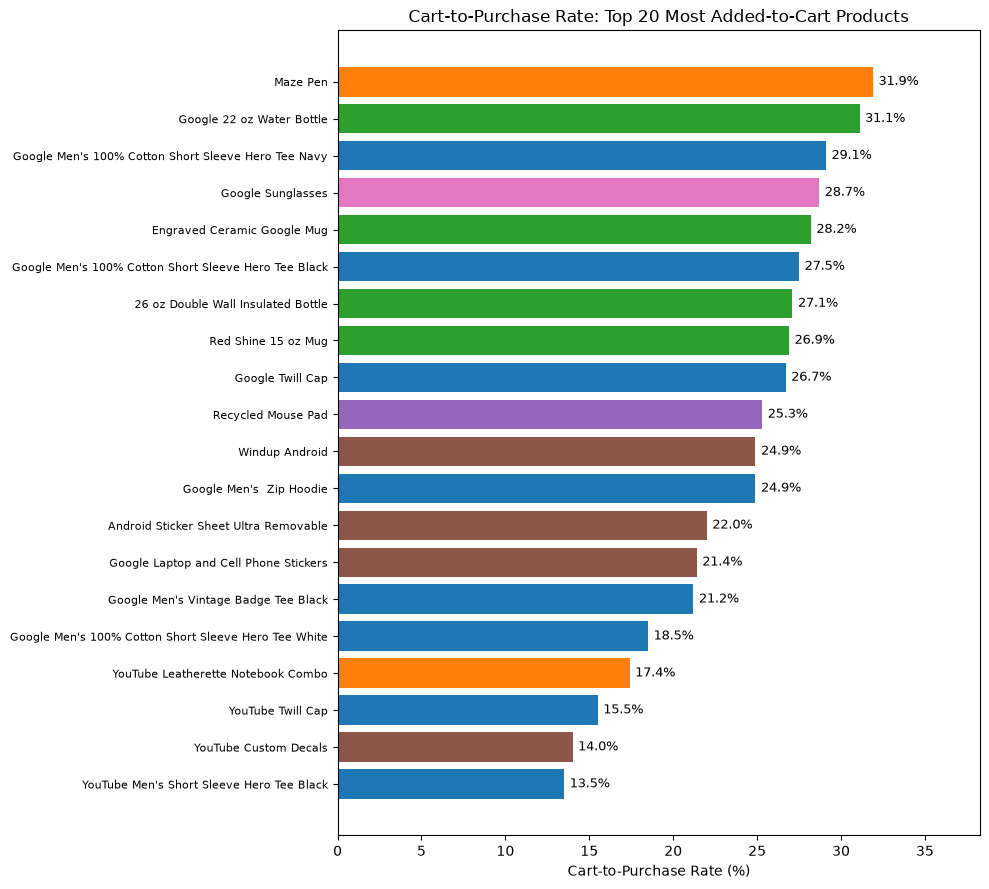

In [23]:
top20_ca = df_ca.nlargest(20, 'sessions_added_to_cart').sort_values('cart_to_purchase_pct')
bar_colors_ca = [cat_colors.get(c, 'tab:gray') for c in top20_ca['normalized_category']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top20_ca['product_name'], top20_ca['cart_to_purchase_pct'], color=bar_colors_ca)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
ax.set_xlabel('Cart-to-Purchase Rate (%)')
ax.set_title('Cart-to-Purchase Rate: Top 20 Most Added-to-Cart Products')
ax.tick_params(axis='y', labelsize=8)
ax.margins(x=0.2)

plt.tight_layout()
plt.savefig('../images/cart_to_purchase_product_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **YouTube-branded items consistently underperform Google equivalents in cart-to-purchase rate**, suggesting weaker purchase intent or higher price sensitivity among YouTube shoppers:
  - Men's Tee Black: Google 27.5% vs YouTube 13.5%
  - Twill Cap: Google 26.7% vs YouTube 15.5%
  - Decals / Stickers: Google 21.4% vs YouTube 14.0%
- **Accessories convert best into the cart but worst out of it** - 41.0% view-to-cart (Section 6) but only 21.7% cart-to-purchase; stickers and decals are likely added as impulse add-ons and abandoned if the session does not result in a primary purchase
- **Office has the highest cart-to-purchase rate (28.9%)** - consistent with bulk gifting behavior; once journals and notebooks enter the cart, the purchase is committed
- **Bags recover well once in cart (24.3%)** - the conversion problem for bags is at the view-to-cart stage (17.8% in Section 6), not the cart-to-purchase stage; priority is getting shoppers to add, not retaining them after
- **Median cart-to-purchase rate is 25.4%** across 442 qualifying products - roughly 3 in 4 add-to-cart sessions do not result in a purchase

## 8. Brand Comparison (Google vs YouTube vs Others)
*Does brand affect how shoppers engage and convert?*

Two approaches: 
- (1) overall brand-level rates aggregated across all products per brand; 
- (2) matched pairs — products that are near-identical except for the brand, isolating the brand effect directly.

In [24]:
# overall brand summary 
brand_rev = (
    df_top_products.groupby('brand', as_index=False)
    .agg(total_revenue = ('total_revenue', 'sum'),
         product_count = ('product_name', 'count'))
)

brand_vtc = (
    df_vtc.dropna(subset=['brand']).groupby('brand', as_index=False)
    .agg(sessions_viewed = ('sessions_viewed', 'sum'),
         vtc_atc = ('sessions_added_to_cart', 'sum'))
)
brand_vtc['view_to_cart_pct'] = (brand_vtc['vtc_atc'] / brand_vtc['sessions_viewed'] * 100).round(1)

brand_ca = (
    df_ca.dropna(subset=['brand']).groupby('brand', as_index=False)
    .agg(sessions_atc =('sessions_added_to_cart', 'sum'),
         sessions_purchased = ('sessions_purchased', 'sum'))
)
brand_ca['cart_to_purchase_pct'] = (brand_ca['sessions_purchased'] / brand_ca['sessions_atc'] * 100).round(1)

df_brand = (
    brand_rev
    .merge(brand_vtc[['brand', 'sessions_viewed', 'view_to_cart_pct']], on='brand', how='left')
    .merge(brand_ca[['brand', 'sessions_atc', 'cart_to_purchase_pct']],  on='brand', how='left')
)
df_brand['revenue_share_pct'] = (df_brand['total_revenue'] / df_brand['total_revenue'].sum() * 100).round(1)
df_brand = df_brand.sort_values('total_revenue', ascending=False)

print("Overall brand summary:")
df_brand[['brand', 'product_count', 'total_revenue', 'revenue_share_pct',
           'view_to_cart_pct', 'cart_to_purchase_pct']]

Overall brand summary:


,brand,product_count,total_revenue,revenue_share_pct,view_to_cart_pct,cart_to_purchase_pct
1,Google,250,989476.89,56.8,30.8,25.4
2,Other,121,513451.65,29.5,30.2,26.9
4,YouTube,39,127716.41,7.3,34.9,16.0
0,Android,69,107077.72,6.1,35.8,24.1
3,Waze,11,4324.32,0.2,30.9,12.3


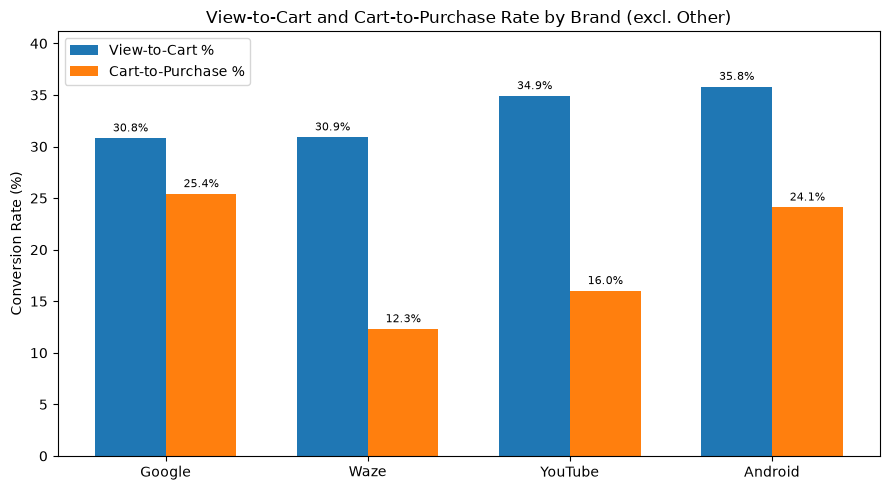

In [25]:
brands_plot = df_brand[df_brand['brand'] != 'Other'].sort_values('view_to_cart_pct')

x = range(len(brands_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], brands_plot['view_to_cart_pct'],
               width, label='View-to-Cart %', color='tab:blue')
bars2 = ax.bar([i + width/2 for i in x], brands_plot['cart_to_purchase_pct'],
               width, label='Cart-to-Purchase %', color='tab:orange')

ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(brands_plot['brand'])
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('View-to-Cart and Cart-to-Purchase Rate by Brand (excl. Other)')
ax.legend()
ax.margins(y=0.15)

plt.tight_layout()
plt.savefig('../images/brand_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# 3-way matched pairs: Google vs YouTube vs Android
pair_names = [
    "Google Twill Cap",          "YouTube Twill Cap",          "Android Twill Cap",
    "Google RFID Journal",       "YouTube RFID Journal",       "Android RFID Journal",
    "Google Hard Cover Journal", "YouTube Hard Cover Journal", "Android Hard Cover Journal",
    "Google Men's Vintage Tank", "YouTube Men's Vintage Tank", "Android Men's Vintage Tank",
]

pair_order  = ["Twill Cap", "RFID Journal", "Hard Cover Journal", "Vintage Tank"]
brand_order = {"Google": 0, "YouTube": 1, "Android": 2}
pair_label  = {
    "Google Twill Cap":          "Twill Cap",
    "YouTube Twill Cap":         "Twill Cap",
    "Android Twill Cap":         "Twill Cap",
    "Google RFID Journal":       "RFID Journal",
    "YouTube RFID Journal":      "RFID Journal",
    "Android RFID Journal":      "RFID Journal",
    "Google Hard Cover Journal": "Hard Cover Journal",
    "YouTube Hard Cover Journal":"Hard Cover Journal",
    "Android Hard Cover Journal":"Hard Cover Journal",
    "Google Men's Vintage Tank": "Vintage Tank",
    "YouTube Men's Vintage Tank":"Vintage Tank",
    "Android Men's Vintage Tank":"Vintage Tank",
}

metrics = (
    df_top_products[['product_name', 'brand', 'total_revenue', 'purchase_rows', 'unit_price']]
    .merge(df_vtc[['product_name', 'sessions_viewed', 'view_to_cart_pct']], on='product_name', how='left')
    .merge(df_ca[['product_name', 'sessions_added_to_cart', 'cart_to_purchase_pct']],  on='product_name', how='left')
)

df_pairs = metrics[metrics['product_name'].isin(pair_names)].copy()
df_pairs['pair']        = df_pairs['product_name'].map(pair_label)
df_pairs['pair_order']  = df_pairs['pair'].map({p: i for i, p in enumerate(pair_order)})
df_pairs['brand_order'] = df_pairs['brand'].map(brand_order)
df_pairs = df_pairs.sort_values(['pair_order', 'brand_order']).drop(columns=['pair_order', 'brand_order'])

df_pairs[['pair', 'product_name', 'brand', 'unit_price', 'total_revenue',
           'sessions_viewed', 'view_to_cart_pct', 'cart_to_purchase_pct']]

,pair,product_name,brand,unit_price,total_revenue,sessions_viewed,view_to_cart_pct,cart_to_purchase_pct
14,Twill Cap,Google Twill Cap,Google,10.35,18445.83,2878,43.8,26.7
26,Twill Cap,YouTube Twill Cap,YouTube,10.05,13919.59,2557,42.7,15.5
79,Twill Cap,Android Twill Cap,Android,9.99,6056.67,362,30.7,35.3
148,RFID Journal,Google RFID Journal,Google,11.47,2959.84,473,12.7,29.7
258,RFID Journal,YouTube RFID Journal,YouTube,6.98,1416.91,1037,8.8,14.0
398,RFID Journal,Android RFID Journal,Android,12.1,229.87,408,7.1,13.6
9,Hard Cover Journal,Google Hard Cover Journal,Google,13.94,25432.67,549,30.6,34.9
25,Hard Cover Journal,YouTube Hard Cover Journal,YouTube,13.59,14379.76,670,21.6,25.5
387,Hard Cover Journal,Android Hard Cover Journal,Android,13.6,271.98,208,19.7,11.4
187,Vintage Tank,Google Men's Vintage Tank,Google,17.03,2281.46,321,34.6,33.5


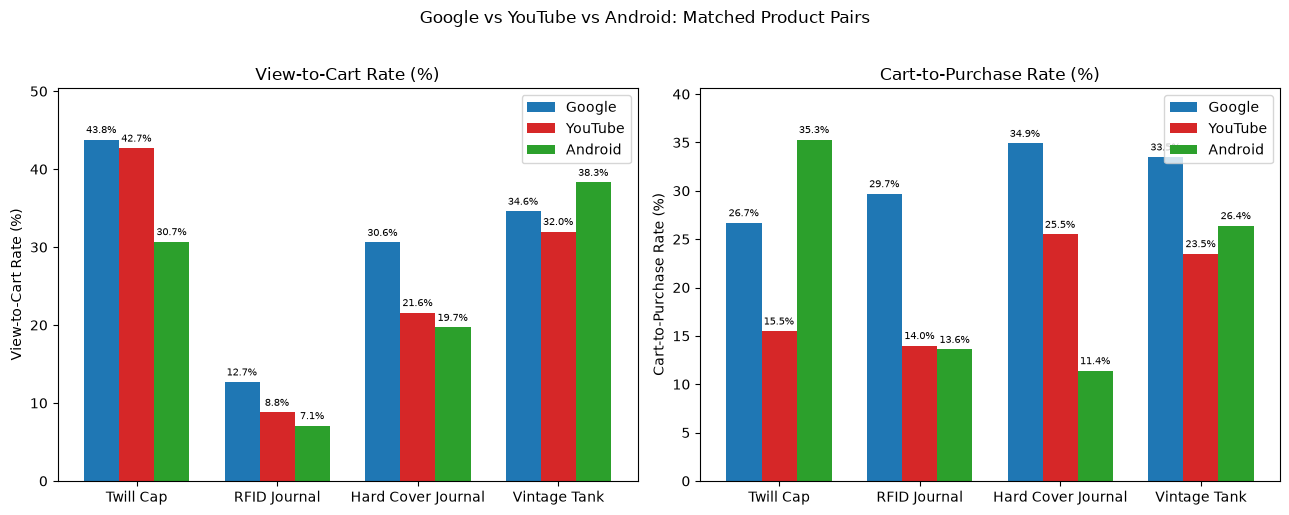

In [27]:
pair_order = ["Twill Cap", "RFID Journal", "Hard Cover Journal", "Vintage Tank"]
g = df_pairs[df_pairs['brand'] == 'Google' ].set_index('pair').loc[pair_order]
y = df_pairs[df_pairs['brand'] == 'YouTube'].set_index('pair').loc[pair_order]
a = df_pairs[df_pairs['brand'] == 'Android'].set_index('pair').loc[pair_order]

x = range(len(pair_order))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [
    (axes[0], 'view_to_cart_pct',    'View-to-Cart Rate (%)'),
    (axes[1], 'cart_to_purchase_pct', 'Cart-to-Purchase Rate (%)'),
]:
    b1 = ax.bar([i - width for i in x], g[metric], width, label='Google',  color='tab:blue')
    b2 = ax.bar([i          for i in x], y[metric], width, label='YouTube', color='tab:red')
    b3 = ax.bar([i + width  for i in x], a[metric], width, label='Android', color='tab:green')
    ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=7)
    ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=7)
    ax.bar_label(b3, fmt='%.1f%%', padding=3, fontsize=7)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pair_order)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.margins(y=0.15)

plt.suptitle('Google vs YouTube vs Android: Matched Product Pairs', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../images/brand_pairs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Google dominates revenue despite fewer unique advantages at the product level** - 56.8% of total revenue from 250 products; Android (35.8%) and YouTube (34.9%) show higher aggregate view-to-cart rates than Google (30.8%), but this is driven by their brand-exclusive products — in matched pairs, Google has equal or higher view-to-cart rate than YouTube across all 4 comparisons
- **Google wins cart-to-purchase in matched pairs** - Google cart-to-purchase exceeds YouTube in all 4 pairs and Android in 3 of 4; the Twill Cap is the only exception where Android (35.3%) leads Google (26.7%)
- **Google converts better even when priced higher** - Vintage Tank: Google `$17.03` vs YouTube `$14.49` vs Android `$14.42`, yet Google cart-to-purchase (33.5%) leads both; RFID Journal: Google `$11.47` vs YouTube `$6.98`, yet Google cart-to-purchase (29.7%) is more than 2x YouTube (14.0%); shoppers pay a premium for the Google brand and are more likely to follow through
- **Android Twill Cap is the one exception** - lowest view-to-cart (30.7%) but highest cart-to-purchase (35.3%) of all 3 brands; a small, highly committed buyer base that rarely browses but almost always follows through
- **YouTube and Android collapse on journals** - both underperform Google at cart-to-purchase by 2x or more across RFID and Hard Cover Journals, suggesting Google brand association matters most for considered purchases like stationery

## 9. Revenue per Visit
*Which products generate the most revenue per detail-view session?*

Total revenue divided by sessions with a detail view — a yield metric that rewards both high conversion and high price. A product with modest traffic but high yield is a better candidate for promotion than one with high traffic but low yield.

In [28]:
query_rev_per_view = """
WITH detail_views AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '2'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
    GROUP BY fullVisitorId, visitId, product_name
),
purchase_revenue AS (
    SELECT
        fullVisitorId,
        visitId,
        product.v2ProductName AS product_name,
        SUM(product.productRevenue / 1000000) AS session_revenue
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product
    WHERE trafficSource.source != 'analytics.google.com'
        AND hits.eCommerceAction.action_type = '6'
        AND (product.isImpression IS NULL OR product.isImpression = FALSE)
        AND product.productRevenue IS NOT NULL
    GROUP BY fullVisitorId, visitId, product_name
)
SELECT
    d.product_name,
    COUNT(*) AS sessions_with_detail_view,
    COUNT(p.visitId) AS sessions_that_purchased,
    ROUND(SUM(COALESCE(p.session_revenue, 0)), 2) AS revenue_from_detail_view_sessions,
    ROUND(SAFE_DIVIDE(SUM(COALESCE(p.session_revenue, 0)),COUNT(*)), 2) AS revenue_per_detail_view
FROM detail_views d
LEFT JOIN purchase_revenue p USING (fullVisitorId, visitId, product_name)
GROUP BY d.product_name
HAVING COUNT(*) >= 50
ORDER BY revenue_per_detail_view DESC
"""

df_rev_per_view = client.query(query_rev_per_view).to_dataframe()
df_rev_per_view = df_rev_per_view.merge(
    df_product_category_norm[['v2ProductName', 'normalized_category', 'brand']],
    left_on='product_name', right_on='v2ProductName', how='left'
).drop(columns='v2ProductName')
df_rev_per_view = df_rev_per_view.merge(
    df_top_products[['product_name', 'unit_price']], on='product_name', how='left'
)

df_rev_per_view['units_per_session'] = (
    df_rev_per_view['revenue_per_detail_view'] / df_rev_per_view['unit_price']
).round(2)

print(f"Products with >=50 detail-view sessions: {len(df_rev_per_view)}")
print(f"Median revenue per detail-view session: ${df_rev_per_view['revenue_per_detail_view'].median():.2f}")
print(f"\nTop 20 by revenue per detail-view session:")
df_rev_per_view.head(20)[['product_name', 'normalized_category', 'unit_price',
                           'sessions_with_detail_view', 'sessions_that_purchased',
                           'revenue_from_detail_view_sessions', 'revenue_per_detail_view',
                           'units_per_session']]

Products with >=50 detail-view sessions: 399
Median revenue per detail-view session: $2.85

Top 20 by revenue per detail-view session:


,product_name,normalized_category,unit_price,sessions_with_detail_view,sessions_that_purchased,revenue_from_detail_view_sessions,revenue_per_detail_view,units_per_session
0,Google Men's Heavyweight Long Sleeve Hero Tee Navy,Apparel,39.61,225,16,9261.11,41.16,1.04
1,Google 25 oz Red Stainless Steel Bottle,Drinkware,12.43,224,26,4600.56,20.54,1.65
2,UFO Bluetooth Water Resistant Speaker,Electronics,34.53,94,4,1930.36,20.54,0.59
3,Recycled Paper Journal Set,Office,3.58,562,97,10369.19,18.45,5.15
4,Google Spiral Journal with Pen,Office,8.15,118,18,2120.91,17.97,2.2
5,Google 22 oz Water Bottle,Drinkware,2.83,1388,288,22723.54,16.37,5.78
6,Google Baby Essentials Set,Apparel,28.9,601,141,9812.24,16.33,0.57
7,Leatherette Journal,Office,9.5,1713,243,26491.90,15.47,1.63
8,Google Metallic Notebook Set,Office,5.3,1440,213,22221.75,15.43,2.91
9,Google Women's Quilted Insulated Vest Black,Apparel,65.66,328,37,4368.40,13.32,0.2


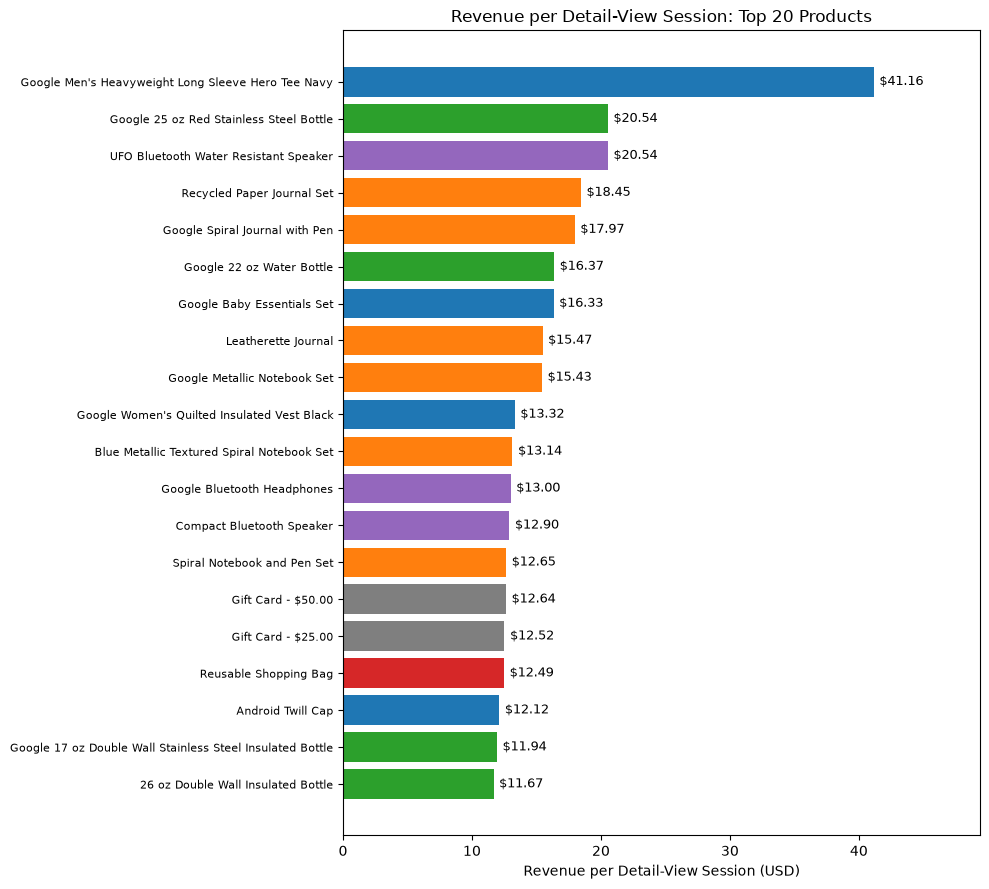

In [29]:
top20_rpv = df_rev_per_view.head(20).sort_values('revenue_per_detail_view')
bar_colors_rpv = [cat_colors.get(c, 'tab:gray') for c in top20_rpv['normalized_category']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top20_rpv['product_name'], top20_rpv['revenue_per_detail_view'], color=bar_colors_rpv)
ax.bar_label(bars, labels=[f"${v:.2f}" for v in top20_rpv['revenue_per_detail_view']], padding=4, fontsize=9)
ax.set_xlabel('Revenue per Detail-View Session (USD)')
ax.set_title('Revenue per Detail-View Session: Top 20 Products')
ax.tick_params(axis='y', labelsize=8)
ax.margins(x=0.2)

plt.tight_layout()
plt.savefig('../images/revenue_per_view.png', dpi=150, bbox_inches='tight')
plt.show()

**Insights:**

- **Two distinct drivers of high revenue per detail-view session:**
  - **High unit price** - Vest (`$65.66`), Headphones (`$47.86`), Speaker (`$56.64`), Gift Cards (`$27-53`); each purchase generates large revenue even with modest conversion
  - **Bulk buying at low unit price** - 22 oz Water Bottle (`$2.83`), Recycled Paper Journal Set (`$3.58`), Metallic Notebook Set (`$5.30`); cheap items bought in large quantities per session, likely corporate gifting
- **The Heavyweight Navy Tee tops the list at `$41.16`/session** (`$39.61` unit price, 16 purchases from 225 views) - combines a premium price point with a reasonable session purchase rate; the best single product to drive more traffic to
- **High-traffic + high-yield products generate the most incremental revenue per unit of traffic investment** - 26 oz Double Wall Bottle (3,424 views, `$11.67`/session) and Leatherette Journal (1,713 views, `$15.47`/session) already produce the highest total revenue from the detail-view path; even a small traffic increase here outweighs a larger lift on a low-volume product
- **Median is `$2.85`/session** across 399 qualifying products - the top 20 all exceed 4x the median, confirming that most product pages generate very little revenue per visit; concentrating discovery on high-yield pages would improve overall store efficiency

## 10. Summary

### Key Findings

**Revenue concentration**
- Top 20% of products (98 SKUs) account for 69.4% of revenue - notable concentration, but not an extreme long tail; the bottom 50% contribute only 7.5%
- Apparel dominates at 39.3% of total revenue (`$684K`); Office leads in units (94,669) at low average price (`$3.78`/unit effective avg), driven by bulk journal and notebook orders

**Funnel conversion**
- Median view-to-cart rate is 32.3%; Bags and Electronics are the weakest at ~18% - high-consideration categories where shoppers browse but hesitate
- Accessories convert best into the cart (~41% view-to-cart) but poorly out of it (~22% cart-to-purchase); low price and high impulse get products into carts, but some friction prevents follow-through

**Brand effect**
- Google accounts for 56.8% of revenue from 250 products; YouTube and Android show higher aggregate view-to-cart rates, but this reflects product mix, not brand strength
- In matched-pair comparisons (same product, different brand), Google cart-to-purchase exceeds YouTube in all 4 pairs and Android in 3 of 4 (Android Twill Cap is the one exception at 35.3% vs Google 26.7%)
- YouTube brand underperforms most clearly on journals, where Google cart-to-purchase is 2x or more; for stationery, brand association to Google's productivity identity appears to matter

**Revenue per visit**
- Median revenue per detail-view session is `$2.85` across 399 qualifying products - the top 20 all exceed 4x the median
- Two distinct yield drivers: high unit price (Vest `$65.66`/unit, Headphones `$47.86`/unit - even modest purchase rates generate large per-session revenue) and bulk buying (22 oz Water Bottle 5.78 units/session, Recycled Paper Journal Set 5.15 units/session)
- Highest-traffic high-yield products (eg. 26 oz Double Wall Bottle & Leatherette Journal) are the most efficient targets for incremental traffic investment

### Recommendations

1. **Promote high-yield, high-traffic products first**: Water Bottle, Leatherette Journal, and Metallic Notebook Set combine volume and yield - incremental ad spend on these compounds quickly
2. **Investigate Bags/Electronics view-to-cart gap**: both categories draw high traffic but convert at ~18%; a pricing or description audit may recover meaningful cart adds without changing traffic
3. **Apply cart recovery to YouTube-branded items**: YouTube products exit the cart at a much higher rate than Google equivalents; targeted email or on-site nudges at the cart stage could partially close the gap
4. **Test a modest price increase on Google-branded items**: matched pairs show Google converts at 2x YouTube's cart-to-purchase rate even when priced higher; this suggests pricing power - demand is relatively inelastic for the Google brand
5. **Shift Office promotion toward bulk buyers**: Office has the highest unit volume and strong revenue per detail-view session for journal sets - positioning these for corporate gifting or bundling could increase AOV